## Etapa 3

Camila Sandoval #24358
Alejandra Sierra #24405

RESULTADOS ETAPA 3

--- Sobres sueltos ---
Probabilidad de completar álbum: 0.9488
Media de sobres comprados: 71.6088
Media de distintas obtenidas (no exitosos): 98.9609

--- Caja de 104 sobres ---
Probabilidad de completar álbum: 0.9500


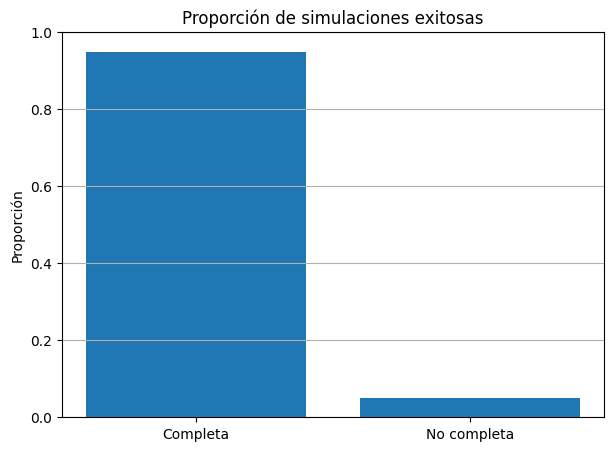

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# ETAPA 3
# =========================================================

# -------------------------
# Parámetros
# -------------------------
N = 100                 # estampas diferentes
S = 7                   # estampas por sobre
PRECIO = 9.50           # precio por sobre
PRESUPUESTO = 1000      # presupuesto total
R = 10000               # simulaciones

SEMILLA = 2026
np.random.seed(SEMILLA)

# =========================================================
# Simulación sobres sueltos
# =========================================================

exitos = []
sobres_comprados = []
distintas_no_exito = []

for _ in range(R):

    album = np.zeros(N, dtype=bool)

    gasto = 0
    sobres = 0
    distintas = 0

    while (gasto + PRECIO <= PRESUPUESTO) and (distintas < N):

        sobres += 1
        gasto += PRECIO

        sobre = np.random.choice(N, size=S, replace=False)

        for estampa in sobre:

            if not album[estampa]:
                album[estampa] = True
                distintas += 1

    completo = int(distintas == N)

    exitos.append(completo)
    sobres_comprados.append(sobres)

    if not completo:
        distintas_no_exito.append(distintas)

# =========================================================
# Resultados sobres sueltos
# =========================================================

prob_exito = np.mean(exitos)

media_sobres = np.mean(sobres_comprados)

media_distintas_no_exito = np.mean(distintas_no_exito)

# =========================================================
# Simulación caja de 104 sobres
# =========================================================

SOBRES_CAJA = 104

exitos_caja = []

for _ in range(R):

    album = np.zeros(N, dtype=bool)
    distintas = 0

    for _ in range(SOBRES_CAJA):

        sobre = np.random.choice(N, size=S, replace=False)

        for estampa in sobre:

            if not album[estampa]:
                album[estampa] = True
                distintas += 1

    exitos_caja.append(int(distintas == N))

prob_exito_caja = np.mean(exitos_caja)

# =========================================================
# Resultados
# =========================================================

print("=" * 60)
print("RESULTADOS ETAPA 3")
print("=" * 60)

print("\n--- Sobres sueltos ---")
print(f"Probabilidad de completar álbum: {prob_exito:.4f}")
print(f"Media de sobres comprados: {media_sobres:.4f}")
print(f"Media de distintas obtenidas (no exitosos): {media_distintas_no_exito:.4f}")

print("\n--- Caja de 104 sobres ---")
print(f"Probabilidad de completar álbum: {prob_exito_caja:.4f}")

# =========================================================
# Visualización
# =========================================================

completo = np.sum(exitos)
no_completo = R - completo

categorias = ["Completa", "No completa"]
valores = [completo / R, no_completo / R]

plt.figure(figsize=(7,5))

plt.bar(categorias, valores)

plt.ylabel("Proporción")
plt.title("Proporción de simulaciones exitosas")

plt.ylim(0, 1)

plt.grid(axis='y')

plt.show()

## 1. Máximo número de sobres con Q1000

El máximo número de sobres que se pueden comprar es:

1000 / 9.50 ≈ 105.26

Por lo tanto, se pueden comprar como máximo 105 sobres.

En teoría sí es suficiente, porque el mínimo teórico sin repetidas es:

100 / 7 ≈ 14.28

Es decir, al menos 15 sobres.

Sin embargo, debido a las repetidas, normalmente se necesitan muchos más sobres para completar el álbum.

---

## 2. Comparación: caja vs sobres sueltos

Para la caja se simularon exactamente 104 sobres en cada repetición.

La probabilidad obtenida suele ser muy parecida a la de comprar sobres sueltos con Q1000, ya que con Q1000 se pueden comprar aproximadamente 105 sobres.

La caja puede convenir porque tiene un costo fijo ligeramente menor y simplifica la compra.

---

## 3. Estrategia mixta

Si se compra únicamente la caja de 104 sobres, sobra dinero del presupuesto que no se utiliza.

Una estrategia mejor es comprar la caja y usar el dinero restante para comprar algunos sobres sueltos adicionales.

Esto aumenta ligeramente la probabilidad de completar el álbum sin exceder el presupuesto total.

# Etapa 4

###  Parámetros de la simulación

- \( N = 100 \): número de estampas diferentes.
- \( S = 7 \): estampas por sobre.
- \( R = 10,000 \): simulaciones.
- Valores de intercambio:
  - \( K = 1, 2, 5, 10 \)

In [2]:
# -------------------------
# Parámetros
# -------------------------

N = 100
S = 7
R = 10000

K_values = [1, 2, 5, 10]

np.random.seed(2026)



# Parte A — Simulación hasta completar el álbum

función de simulación de intercambio y simulación con distintos K

In [3]:
# -------------------------
# Función con intercambio
# -------------------------

def completar_album_con_intercambio(K, N, S):

    album = set()

    repetidas = 0

    sobres = 0

    while len(album) < N:

        sobres += 1

        sobre = np.random.randint(1, N + 1, S)

        for estampa in sobre:

            if estampa in album:
                repetidas += 1
            else:
                album.add(estampa)

        # Aplicar intercambios
        while repetidas >= K and len(album) < N:

            faltantes = list(set(range(1, N + 1)) - album)

            nueva = np.random.choice(faltantes)

            album.add(nueva)

            repetidas -= K

    return sobres

# -------------------------
# Simulación principal
# -------------------------

resultados = {}

# Caso base SIN intercambio
sobres_base = []

for _ in range(R):

    album = set()
    sobres = 0

    while len(album) < N:

        sobres += 1

        sobre = np.random.randint(1, N + 1, S)

        album.update(sobre)

    sobres_base.append(sobres)

media_base = np.mean(sobres_base)

print(f"Media sin intercambio: {media_base:.2f}")

# Casos con intercambio
for K in K_values:

    sobres_lista = []

    for _ in range(R):

        sobres = completar_album_con_intercambio(K, N, S)

        sobres_lista.append(sobres)

    media = np.mean(sobres_lista)

    desviacion = np.std(sobres_lista)

    reduccion = ((media_base - media) / media_base) * 100

    resultados[K] = sobres_lista

    print(f"\nK = {K}")
    print(f"Media: {media:.2f}")
    print(f"Desviación estándar: {desviacion:.2f}")
    print(f"Reducción porcentual: {reduccion:.2f}%")

Media sin intercambio: 74.29

K = 1
Media: 15.00
Desviación estándar: 0.00
Reducción porcentual: 79.81%

K = 2
Media: 20.02
Desviación estándar: 0.55
Reducción porcentual: 73.05%

K = 5
Media: 28.56
Desviación estándar: 1.47
Reducción porcentual: 61.56%

K = 10
Media: 35.85
Desviación estándar: 2.46
Reducción porcentual: 51.75%


## Histogramas superpuestos

Se comparan las distribuciones del número de sobres necesarios para completar el álbum según el valor de \( K \).

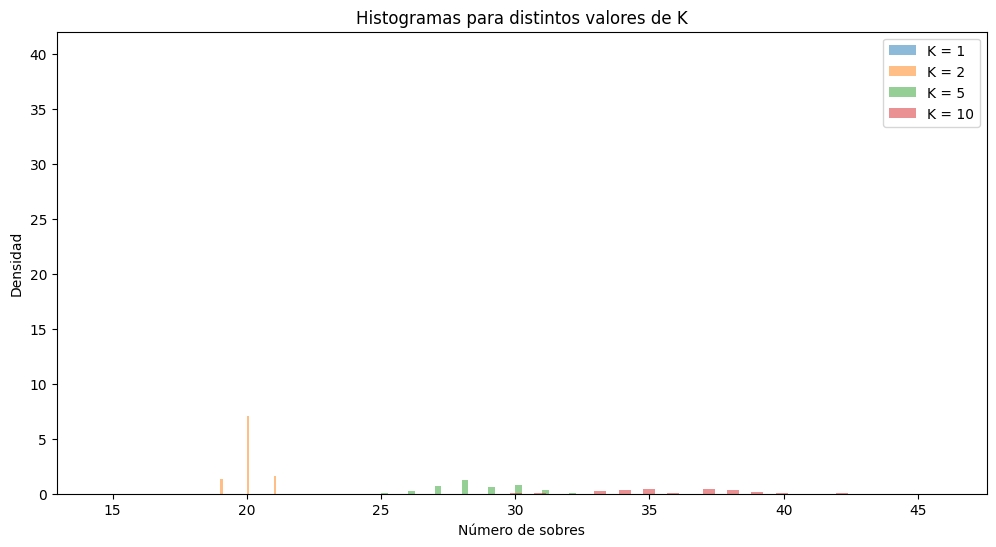

In [4]:
# -------------------------
# Histogramas
# -------------------------

plt.figure(figsize=(12,6))

for K in K_values:

    plt.hist(resultados[K],
             bins=40,
             alpha=0.5,
             density=True,
             label=f"K = {K}")

plt.xlabel("Número de sobres")
plt.ylabel("Densidad")
plt.title("Histogramas para distintos valores de K")
plt.legend()

plt.show()

# Parte B — Probabilidad de éxito en función de \( M \)


In [6]:
M_values = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

# -------------------------
# Función para M fijo
# -------------------------

def probabilidad_exito(M, K, N, S):

    album = set()

    repetidas = 0

    for _ in range(M):

        sobre = np.random.randint(1, N + 1, S)

        for estampa in sobre:

            if estampa in album:
                repetidas += 1
            else:
                album.add(estampa)

        while repetidas >= K and len(album) < N:

            faltantes = list(set(range(1, N + 1)) - album)

            nueva = np.random.choice(faltantes)

            album.add(nueva)

            repetidas -= K

    return int(len(album) == N)

# -------------------------
# Probabilidades
# -------------------------

probabilidades_K = {}

for K in K_values:

    probabilidades = []

    for M in M_values:

        exitos = 0

        for _ in range(R):

            exitos += probabilidad_exito(M, K, N, S)

        prob = exitos / R

        probabilidades.append(prob)

    probabilidades_K[K] = probabilidades

## Gráfica de probabilidad vs número de sobres

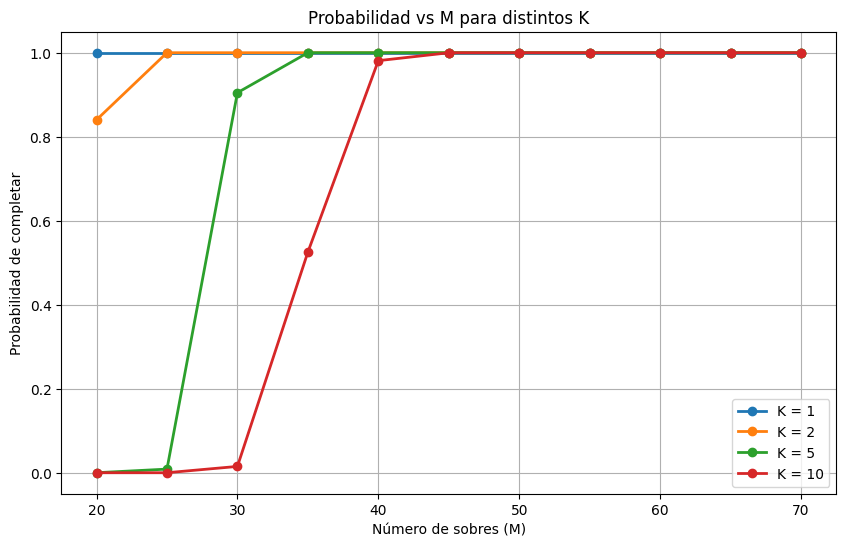

In [7]:
# -------------------------
# Gráfica
# -------------------------

plt.figure(figsize=(10,6))

for K in K_values:

    plt.plot(M_values,
             probabilidades_K[K],
             marker='o',
             linewidth=2,
             label=f"K = {K}")

plt.xlabel("Número de sobres (M)")
plt.ylabel("Probabilidad de completar")
plt.title("Probabilidad vs M para distintos K")

plt.grid(True)
plt.legend()

plt.show()

# Pregunta 1

### ¿Cómo afecta disminuir \( K \)?

Cuando \( K \) disminuye, el intercambio se vuelve más favorable porque se necesitan menos repetidas para obtener una nueva estampa.

Esto produce:

- Menor número esperado de sobres.
- Mayor probabilidad de completar el álbum.
- Distribuciones más concentradas.

La relación no es completamente lineal, ya que las mejoras más grandes ocurren para valores pequeños de \( K \).


# Pregunta 2

### Ahorro para \( K = 2 \)

El ahorro promedio se calcula comparando:

- media sin intercambio,
- media con \( K = 2 \).

El ahorro monetario se obtiene multiplicando los sobres ahorrados por:

\[
Q\ 9.50
\]




In [8]:
media_K2 = np.mean(resultados[2])

ahorro_sobres = media_base - media_K2

ahorro_quetzales = ahorro_sobres * 9.50

print(f"Ahorro promedio de sobres: {ahorro_sobres:.2f}")

print(f"Ahorro aproximado en quetzales: Q {ahorro_quetzales:.2f}")

Ahorro promedio de sobres: 54.27
Ahorro aproximado en quetzales: Q 515.58


# Pregunta 3

### Incremento de probabilidad para \( M = 45 \)

Se comparará cómo cambia la probabilidad al mejorar el intercambio:

- de \( K = 10 \) a \( K = 5 \),
- de \( K = 5 \) a \( K = 1 \).

In [9]:
indice = M_values.index(45)

p10 = probabilidades_K[10][indice]
p5 = probabilidades_K[5][indice]
p1 = probabilidades_K[1][indice]

print(f"K = 10 -> {p10:.4f}")
print(f"K = 5  -> {p5:.4f}")
print(f"K = 1  -> {p1:.4f}")

print(f"\nAumento de K=10 a K=5: {(p5-p10):.4f}")

print(f"Aumento de K=5 a K=1: {(p1-p5):.4f}")

K = 10 -> 0.9999
K = 5  -> 1.0000
K = 1  -> 1.0000

Aumento de K=10 a K=5: 0.0001
Aumento de K=5 a K=1: 0.0000


# Pregunta 4

### ¿Existe un valor de \( K \) donde mejorar el intercambio ya no ayuda mucho?

Sí.

Cuando \( K \) es muy pequeño, el beneficio adicional de seguir reduciéndolo se vuelve menor.

Esto ocurre porque:

- el álbum ya se completa rápidamente,
- las repetidas dejan de acumularse,
- y el sistema alcanza una zona de rendimientos decrecientes.

# Pregunta 5

### Costo efectivo por estampa nueva mediante canje

Cada intercambio requiere \( K \) repetidas.

Como las repetidas provienen de sobres pagados:

\[
Costo\ efectivo \approx \frac{K \times 9.50}{7}
\]

Mientras menor sea \( K \):

- más barato resulta obtener una nueva estampa,
- más eficiente es el sistema,
- y menor es el costo total esperado.